# 04. Forecast Evaluation 
## ARIMA, SARIMA, SARIMAX versus naive benchmarks

This notebook evaluates forecasting performance for the main variable `anxiety`.

**Important interpretation rule:** forecasting is not the central research contribution of the project. The project primarily applies ARIMA, SARIMA, and SARIMAX to study search-behavior dynamics and COVID-period intervention effects. Forecast evaluation is used as a validation exercise.

The benchmark models are included for discipline:

- `Naive`: uses the most recent value as the forecast.
- `Seasonal_Naive`: uses the same month from the previous year as the forecast.

If benchmarks outperform ARIMA/SARIMA/SARIMAX, that does not invalidate the project. It indicates that post-COVID anxiety search behavior is highly persistent or seasonally regular.

This notebook evaluates post-COVID forecast accuracy using raw outputs from `03_Modeling_Enhanced_Final_9point.ipynb`. It does **not** read files that it creates itself.

## A. Import and Path

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path('modeling_outputs')
FIGURES_DIR = Path('figures')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 160)

COUNTRY_DISPLAY = {
    'Australia': 'Australia',
    'Canada': 'Canada',
    'Ireland': 'Ireland',
    'New_Zealand': 'New Zealand',
    'New Zealand': 'New Zealand',
    'UK': 'United Kingdom',
    'US': 'United States',
}

MODEL_DISPLAY = {
    'Naive': 'Naive',
    'Seasonal_Naive': 'Seasonal Naive',
    'Seasonal Naive': 'Seasonal Naive',
    'ARIMA': 'ARIMA',
    'SARIMA': 'SARIMA',
    'SARIMAX': 'SARIMAX',
}

HORIZON_DISPLAY = {
    'h01_03': 'h01-03',
    'h04_12': 'h04-12',
    'h13_24': 'h13-24',
    'h25_plus': 'h25+',
}

def read_result(name: str) -> pd.DataFrame:
    candidates = [RESULTS_DIR / name, Path(name)]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    searched = ' or '.join(str(p) for p in candidates)
    raise FileNotFoundError(f'Cannot find {name}. Searched: {searched}. Run Notebook 03 first, then run this notebook.')

def require_columns(df: pd.DataFrame, cols, table_name: str):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f'{table_name} is missing required columns: {missing}. Available columns: {list(df.columns)}')

def add_display_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'country' in out.columns:
        out['country_label'] = out['country'].map(COUNTRY_DISPLAY).fillna(out['country'])
    if 'model_type' in out.columns:
        out['model_label'] = out['model_type'].map(MODEL_DISPLAY).fillna(out['model_type'])
    if 'best_test_model' in out.columns:
        out['best_test_model_label'] = out['best_test_model'].map(MODEL_DISPLAY).fillna(out['best_test_model'])
    if 'horizon_group' in out.columns:
        out['horizon_label'] = out['horizon_group'].map(HORIZON_DISPLAY).fillna(out['horizon_group'])
    return out


## B. Load raw forecast outputs from Notebook 03

In [2]:

model_eval = read_result('03_final_anxiety_model_class_comparison_enhanced.csv')
dm_raw = read_result('03_anxiety_diebold_mariano_vs_best_benchmark.csv')
horizon_raw = read_result('03_anxiety_horizon_specific_test_errors.csv')
rolling_raw = read_result('03_anxiety_rolling_origin_evaluation.csv')

require_columns(model_eval, ['country', 'model_type', 'test_RMSE', 'test_sMAPE', 'status'], '03_final_anxiety_model_class_comparison_enhanced.csv')
require_columns(dm_raw, ['country', 'model_type', 'benchmark_model', 'mean_loss_diff', 'DM_pvalue'], '03_anxiety_diebold_mariano_vs_best_benchmark.csv')
require_columns(horizon_raw, ['country', 'model_type', 'horizon_group', 'RMSE', 'sMAPE'], '03_anxiety_horizon_specific_test_errors.csv')
require_columns(rolling_raw, ['country', 'origin', 'model_type', 'RMSE', 'sMAPE', 'status'], '03_anxiety_rolling_origin_evaluation.csv')

model_eval = model_eval.replace([np.inf, -np.inf], np.nan)
horizon_raw = horizon_raw.replace([np.inf, -np.inf], np.nan)
rolling_raw = rolling_raw.replace([np.inf, -np.inf], np.nan)

display(model_eval.sort_values(['country', 'test_RMSE']).head(20))


,country,model_type,order,seasonal_order,exog_set,AIC_refit,BIC_refit,test_MAE,test_RMSE,test_sMAPE,resid_n,resid_mean,resid_std,LjungBox_p12,LjungBox_p24,ARCH_LM_p12,JarqueBera_p,status
0,Australia,Seasonal_Naive,NaN,NaN,NaN,NaN,NaN,3.903226,5.220926,4.512262,221,25.877828,24.840372,0.000000e+00,0.000000e+00,1.150542e-34,5.214696e-06,OK
1,Australia,SARIMA,"(1, 1, 1)","(1, 1, 1, 12)",NaN,1118.889277,1138.856534,7.164753,8.630130,8.280262,233,0.024589,4.133190,3.114031e-01,2.837767e-01,3.291416e-10,2.716922e-136,OK
2,Australia,ARIMA,"(3, 1, 1)","(0, 0, 0, 0)",NaN,1397.853829,1418.456161,10.138124,12.874957,11.760900,233,0.117569,5.261999,6.851828e-06,2.907873e-14,8.131982e-03,2.594531e-26,OK
3,Australia,Naive,NaN,NaN,NaN,NaN,NaN,13.935484,15.892786,15.702270,232,-35.754310,25.011426,0.000000e+00,0.000000e+00,3.133835e-39,3.372050e-06,OK
4,Australia,SARIMAX,"(1, 1, 1)","(0, 1, 1, 12)",early_covid_shock+covid_period+covid_trend,1134.396990,1161.019999,37.690423,38.805024,36.730892,233,0.106901,4.246457,1.101892e-02,1.574055e-02,8.376382e-12,1.150869e-162,OK
5,Canada,Seasonal_Naive,NaN,NaN,NaN,NaN,NaN,4.225806,5.064105,4.941757,221,25.122172,24.549921,0.000000e+00,0.000000e+00,6.219140e-36,4.611721e-06,OK
6,Canada,Naive,NaN,NaN,NaN,NaN,NaN,5.064516,5.877788,5.994683,232,-32.323276,24.629616,0.000000e+00,0.000000e+00,1.543177e-39,1.972327e-06,OK
7,Canada,ARIMA,"(2, 1, 1)","(0, 0, 0, 0)",NaN,1351.904717,1369.095113,7.058730,8.992276,8.209179,233,0.156318,4.930108,7.821262e-14,5.059783e-24,1.098711e-02,9.694781e-132,OK
8,Canada,SARIMA,"(1, 1, 1)","(0, 0, 1, 12)",NaN,1210.556372,1227.478848,9.950453,12.302622,11.266078,233,0.067127,4.330844,6.991873e-02,2.639040e-05,1.395791e-01,0.000000e+00,OK
9,Canada,SARIMAX,"(1, 1, 1)","(0, 0, 1, 12)",early_covid_shock+covid_period+covid_trend,1206.151654,1233.227614,20.084105,21.635925,21.343610,233,0.061327,4.257025,4.730056e-02,2.282879e-05,2.096875e-02,0.000000e+00,OK


## C. Best post-COVID forecast model by country

This table is derived directly from Notebook 03's raw test-evaluation output. The code uses `groupby(...).head(1)` rather than `groupby().first()` so each selected row remains internally consistent.

,country,country_label,model_type,model_label,test_RMSE,test_sMAPE
0,Australia,Australia,Seasonal_Naive,Seasonal Naive,5.220926,4.512262
1,Canada,Canada,Seasonal_Naive,Seasonal Naive,5.064105,4.941757
2,Ireland,Ireland,Seasonal_Naive,Seasonal Naive,5.509523,5.252198
3,New_Zealand,New Zealand,Seasonal_Naive,Seasonal Naive,8.226629,7.401847
4,UK,United Kingdom,Seasonal_Naive,Seasonal Naive,4.711003,4.422434
5,US,United States,Naive,Naive,4.299287,3.510255


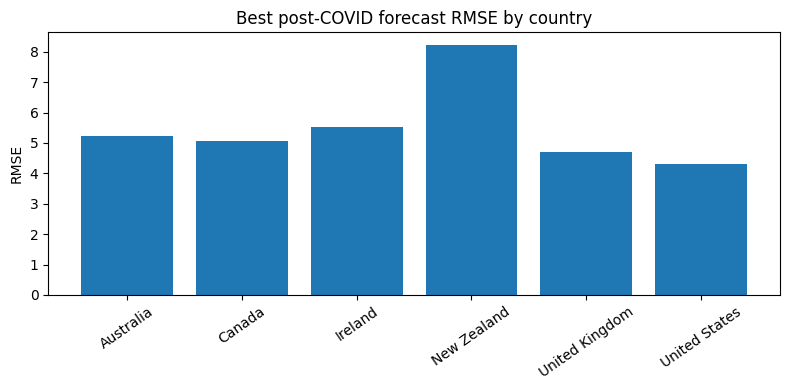

In [3]:

best = (
    model_eval.loc[model_eval['status'].eq('OK')]
    .dropna(subset=['test_RMSE'])
    .sort_values(['country', 'test_RMSE'], na_position='last')
    .groupby('country', group_keys=False)
    .head(1)
    .reset_index(drop=True)
)
best = add_display_columns(best)
best.to_csv(RESULTS_DIR / '04_best_test_forecast_model_by_country.csv', index=False)

display(best[['country', 'country_label', 'model_type', 'model_label', 'test_RMSE', 'test_sMAPE']])

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = best.sort_values('country_label')
ax.bar(plot_df['country_label'], plot_df['test_RMSE'])
ax.set_title('Best post-COVID forecast RMSE by country')
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_best_test_rmse_by_country.png', dpi=160)
plt.show()


## D. Average post-COVID performance by model class

In [4]:

avg = (
    model_eval.loc[model_eval['status'].eq('OK')]
    .groupby('model_type', as_index=False)
    .agg(
        n_countries=('country', 'nunique'),
        test_MAE=('test_MAE', 'mean') if 'test_MAE' in model_eval.columns else ('test_RMSE', 'count'),
        test_RMSE=('test_RMSE', 'mean'),
        test_sMAPE=('test_sMAPE', 'mean'),
    )
)
if 'test_MAE' not in model_eval.columns:
    avg = avg.drop(columns=['test_MAE'])
avg = add_display_columns(avg).sort_values('test_RMSE').reset_index(drop=True)
avg.to_csv(RESULTS_DIR / '04_average_test_performance_by_model_class.csv', index=False)
display(avg)


,model_type,n_countries,test_MAE,test_RMSE,test_sMAPE,model_label
0,Seasonal_Naive,6,4.715054,5.989056,5.542533,Seasonal Naive
1,Naive,6,7.876344,9.312323,9.059933,Naive
2,ARIMA,6,8.745249,10.688439,10.093167,ARIMA
3,SARIMA,6,9.564517,11.395475,10.823158,SARIMA
4,SARIMAX,6,21.883102,23.169350,22.751031,SARIMAX


## E. Diebold-Mariano comparison against the best benchmark

A positive `mean_loss_diff` means the ARIMA/SARIMA/SARIMAX model has higher squared forecast loss than the benchmark. A small p-value means the loss difference is statistically meaningful.

In [5]:

dm = dm_raw.copy()
dm['model_underperforms_benchmark'] = dm['mean_loss_diff'] > 0
dm['significant_5pct'] = dm['DM_pvalue'] < 0.05
dm = add_display_columns(dm)
dm.to_csv(RESULTS_DIR / '04_diebold_mariano_interpreted.csv', index=False)

dm_summary = (
    dm.groupby('model_type', as_index=False)
    .agg(
        n_tests=('country', 'count'),
        n_significant_5pct=('significant_5pct', 'sum'),
        mean_loss_diff=('mean_loss_diff', 'mean'),
        median_pvalue=('DM_pvalue', 'median'),
        share_underperforming=('model_underperforms_benchmark', 'mean'),
    )
)
dm_summary = add_display_columns(dm_summary).sort_values('model_type').reset_index(drop=True)
dm_summary.to_csv(RESULTS_DIR / '04_diebold_mariano_summary.csv', index=False)

display(dm.sort_values(['country', 'model_type']))
display(dm_summary)


,country,model_type,benchmark_model,DM_stat,DM_pvalue,mean_loss_diff,n,interpretation,model_underperforms_benchmark,significant_5pct,country_label,model_label
0,Australia,ARIMA,Seasonal_Naive,3.119852,1.809419e-03,138.506442,31,negative DM means model lower loss than benchmark,True,True,Australia,ARIMA
1,Australia,SARIMA,Seasonal_Naive,2.128483,3.329709e-02,47.221074,31,negative DM means model lower loss than benchmark,True,True,Australia,SARIMA
2,Australia,SARIMAX,Seasonal_Naive,4.387769,1.145194e-05,1478.571803,31,negative DM means model lower loss than benchmark,True,True,Australia,SARIMAX
3,Canada,ARIMA,Seasonal_Naive,1.634839,1.020829e-01,55.215871,31,negative DM means model lower loss than benchmark,True,False,Canada,ARIMA
4,Canada,SARIMA,Seasonal_Naive,1.978287,4.789637e-02,125.709355,31,negative DM means model lower loss than benchmark,True,True,Canada,SARIMA
5,Canada,SARIMAX,Seasonal_Naive,3.198266,1.382567e-03,442.468110,31,negative DM means model lower loss than benchmark,True,True,Canada,SARIMAX
6,Ireland,ARIMA,Seasonal_Naive,2.014160,4.399269e-02,69.444800,31,negative DM means model lower loss than benchmark,True,True,Ireland,ARIMA
7,Ireland,SARIMA,Seasonal_Naive,1.936931,5.275383e-02,54.413597,31,negative DM means model lower loss than benchmark,True,False,Ireland,SARIMA
8,Ireland,SARIMAX,Seasonal_Naive,4.169536,3.052200e-05,1048.406724,31,negative DM means model lower loss than benchmark,True,True,Ireland,SARIMAX
9,New_Zealand,ARIMA,Seasonal_Naive,2.873997,4.053126e-03,158.102510,31,negative DM means model lower loss than benchmark,True,True,New Zealand,ARIMA


,model_type,n_tests,n_significant_5pct,mean_loss_diff,median_pvalue,share_underperforming,model_label
0,ARIMA,6,5,89.140599,0.005758,1.0,ARIMA
1,SARIMA,6,5,106.564735,0.025544,1.0,SARIMA
2,SARIMAX,6,5,601.331297,0.000048,1.0,SARIMAX


## F. Horizon-specific forecast performance

This section separates short horizons from medium and long horizons. It is important because SARIMA can be useful at h01-03 even when seasonal naive dominates the full post-COVID horizon.

,horizon_group,model_type,n_country_horizon_cells,RMSE,sMAPE,model_label,horizon_label
2,h01_03,SARIMA,6,3.775997,3.733044,SARIMA,h01-03
4,h01_03,Seasonal_Naive,6,4.222827,4.374403,Seasonal Naive,h01-03
0,h01_03,ARIMA,6,4.679820,4.688569,ARIMA,h01-03
1,h01_03,Naive,6,5.198562,5.330177,Naive,h01-03
3,h01_03,SARIMAX,6,15.111947,16.101160,SARIMAX,h01-03
9,h04_12,Seasonal_Naive,6,5.442141,5.141544,Seasonal Naive,h04-12
5,h04_12,ARIMA,6,7.055052,6.483099,ARIMA,h04-12
7,h04_12,SARIMA,6,7.351594,6.996798,SARIMA,h04-12
6,h04_12,Naive,6,8.197662,8.016894,Naive,h04-12
8,h04_12,SARIMAX,6,16.969691,17.094342,SARIMAX,h04-12


,horizon_group,horizon_label,model_type,model_label,RMSE,sMAPE
0,h01_03,h01-03,SARIMA,SARIMA,3.775997,3.733044
1,h04_12,h04-12,Seasonal_Naive,Seasonal Naive,5.442141,5.141544
2,h13_24,h13-24,Seasonal_Naive,Seasonal Naive,4.831257,4.510065
3,h25_plus,h25+,Seasonal_Naive,Seasonal Naive,8.426379,8.328663


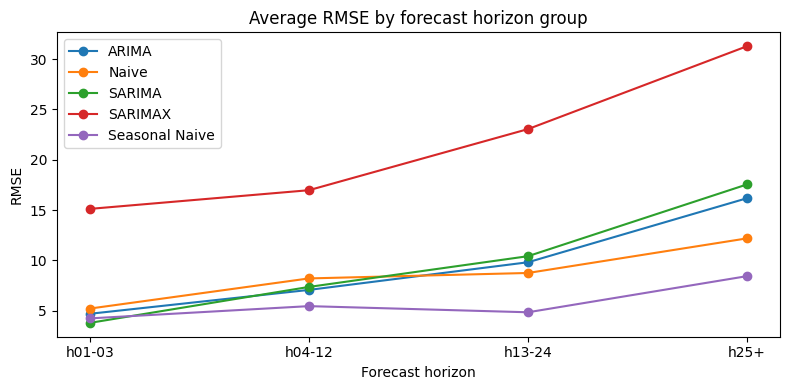

In [6]:

horizon = horizon_raw.copy()
horizon_avg = (
    horizon.groupby(['horizon_group', 'model_type'], as_index=False)
    .agg(
        n_country_horizon_cells=('country', 'count'),
        RMSE=('RMSE', 'mean'),
        sMAPE=('sMAPE', 'mean'),
    )
)
horizon_avg = add_display_columns(horizon_avg)
horizon_avg.to_csv(RESULTS_DIR / '04_horizon_specific_average_errors.csv', index=False)

best_by_horizon = (
    horizon_avg.sort_values(['horizon_group', 'RMSE'], na_position='last')
    .groupby('horizon_group', group_keys=False)
    .head(1)
    .reset_index(drop=True)
)
best_by_horizon.to_csv(RESULTS_DIR / '04_best_average_model_by_horizon_group.csv', index=False)

display(horizon_avg.sort_values(['horizon_group', 'RMSE']))
display(best_by_horizon[['horizon_group', 'horizon_label', 'model_type', 'model_label', 'RMSE', 'sMAPE']])

fig, ax = plt.subplots(figsize=(8, 4))
for model_type, g in horizon_avg.groupby('model_type'):
    ordered = g.copy()
    ordered['h_order'] = ordered['horizon_group'].map({'h01_03': 1, 'h04_12': 2, 'h13_24': 3, 'h25_plus': 4})
    ordered = ordered.sort_values('h_order')
    ax.plot(ordered['horizon_label'], ordered['RMSE'], marker='o', label=MODEL_DISPLAY.get(model_type, model_type))
ax.set_title('Average RMSE by forecast horizon group')
ax.set_xlabel('Forecast horizon')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_average_rmse_by_horizon_group.png', dpi=160)
plt.show()


## G. Rolling-origin robustness

In [7]:

rolling = rolling_raw.loc[rolling_raw['status'].eq('OK')].copy()
rolling_avg = (
    rolling.groupby('model_type', as_index=False)
    .agg(
        n_forecasts=('country', 'count'),
        n_countries=('country', 'nunique'),
        mean_RMSE=('RMSE', 'mean'),
        median_RMSE=('RMSE', 'median'),
        mean_sMAPE=('sMAPE', 'mean'),
    )
)
rolling_avg = add_display_columns(rolling_avg).sort_values('mean_RMSE').reset_index(drop=True)
rolling_avg.to_csv(RESULTS_DIR / '04_rolling_origin_average_performance.csv', index=False)
rolling.to_csv(RESULTS_DIR / '04_rolling_origin_detailed_performance.csv', index=False)

display(rolling_avg)


,model_type,n_forecasts,n_countries,mean_RMSE,median_RMSE,mean_sMAPE,model_label
0,Seasonal_Naive,24,6,5.730213,5.415102,5.538727,Seasonal Naive
1,SARIMA,24,6,6.527620,5.940604,6.344843,SARIMA
2,ARIMA,24,6,6.880577,6.786894,6.489420,ARIMA
3,Naive,24,6,10.469654,8.368127,11.332736,Naive
4,SARIMAX,24,6,10.558502,8.171600,10.537640,SARIMAX


## H. Forecast evaluation summary for report

In [8]:

bench_models = {'Naive', 'Seasonal_Naive', 'Seasonal Naive'}
bench_count = int(best['model_type'].isin(bench_models).sum())
seasonal_count = int(best['model_type'].isin({'Seasonal_Naive', 'Seasonal Naive'}).sum())
short_best = best_by_horizon.loc[best_by_horizon['horizon_group'].eq('h01_03'), 'model_type']
short_best = short_best.iloc[0] if len(short_best) else 'not available'
roll_best = rolling_avg.iloc[0]['model_type'] if not rolling_avg.empty else 'not available'

summary = pd.DataFrame({'forecast_evaluation_summary': [
    f'Benchmark models are the best full post-COVID test models in {bench_count}/6 countries; Seasonal Naive is best in {seasonal_count}/6 countries.',
    f'{MODEL_DISPLAY.get(short_best, short_best)} is the best average model for horizons h01-03, so SARIMA remains useful for short-horizon seasonal dynamics.',
    'Diebold-Mariano tests are interpreted with positive mean loss difference meaning the ARIMA/SARIMA/SARIMAX model underperforms the benchmark.',
    f'Rolling-origin evaluation provides a robustness check; the best average rolling-origin model is {MODEL_DISPLAY.get(roll_best, roll_best)}.',
    'Forecast evaluation should be treated as validation. The central research contribution remains SARIMAX intervention interpretation and cross-country comparison.'
]})
summary.to_csv(RESULTS_DIR / '04_forecast_evaluation_summary.csv', index=False)
display(summary)


,forecast_evaluation_summary
0,Benchmark models are the best full post-COVID ...
1,SARIMA is the best average model for horizons ...
2,Diebold-Mariano tests are interpreted with pos...
3,Rolling-origin evaluation provides a robustnes...
4,Forecast evaluation should be treated as valid...
